<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">

</div>
<div style="float: right; width: 50%;">

<p style="margin: 0; text-align:right;">2024-25 · Exploratory Data Analysis</p>
<p style="margin: 0; text-align:right; padding-button: 100px;">Grado en Ciencia de Datos y Grado en Física</p>
<p style="margin: 0; text-align:right; padding-button: 100px;">By Ignacio Ibáñez Micó and Miquel Roca Riera</p>
</div>
</div>
<div style="width:100%;">&nbsp;</div>


# Time series exercise


In [ ]:
import pickle

import scipy.stats
import numpy as np
import pandas as pd
import matplotlib as mpl
from sklearn import svm
from sklearn import ensemble
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm

%matplotlib inline

For the exercise, we will use the *AirPassangers* dataset, which contains information about the number of flights made over many years.

The first thing we will do is read the data and observe its distribution.

In [ ]:
data = pd.read_csv('AirPassengers.csv', parse_dates=['Month'], index_col='Month', header=0)
data.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


<Axes: xlabel='Month'>

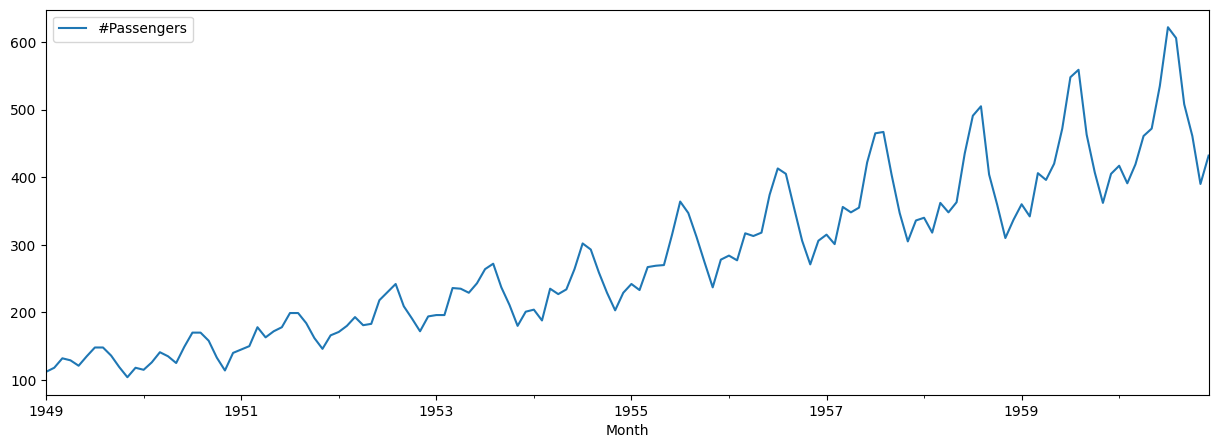

In [ ]:
data.plot(figsize=(15, 5))

<div style="background-color: #567c9b; border-color: #111921; border-left: 5px solid #5288be; padding: 0.5em;">
<strong>Implementation:</strong>
Describe the aspects you see in the time series and explain the strategy to be used (0.25 points).
</div>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Answer:</strong>




</div>

We see a non stationary periodic series, with a lineal growing trend,  in which the mean and variance grow over time in a heteroscedastic data set. I would use a High variance and low bias model to make the most predictive model.

Before we start dealing with the different components of a time series, we will remove a couple of years of data from the original dataset. This way, when we make a future prediction, we can check if it matches the actual data.





In [ ]:
TEST_SIZE = 24 #2 years of data we selected
train, test = data.iloc[:-TEST_SIZE], data.iloc[-TEST_SIZE:] #we use iloc tu index the data (split the dataset)
#train = -TEST_SIZE hasta llegar a los últimos 24 registros /// test = Toma únicamente los últimos 24 registros (-TEST_SIZE:) "examenes"
x_train, x_test = np.array(range(train.shape[0])), np.array(range(train.shape[0], data.shape[0]))
#Como estás analizando vuelos a lo largo del tiempo, necesitas una variable numérica que represente ese avance temporal (el eje X).
#x_train = Crea un array que va de 0 hasta el número de filas en el set de entrenamiento
#x_test: Continúa la secuencia justo donde se quedó x_train hasta el final del dataset.
train.shape, x_train.shape, test.shape, x_test.shape

((120, 1), (120,), (24, 1), (24,))

Text(0.5, 1.0, 'Training and testing predictions')

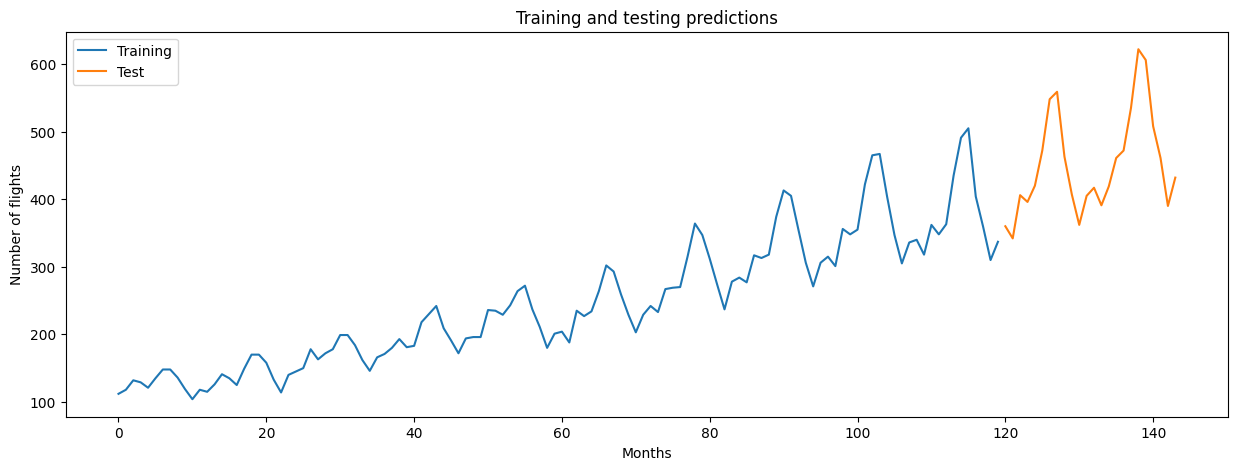

In [ ]:
#Double graphic
fig, ax = plt.subplots(1, 1, figsize=(15, 5))#plt.subplots(1, 1): create a graphic consisting of 1 row and 1 column. 
ax.plot(x_train, train)
ax.plot(x_test, test) #Last 24 months (orange)
ax.legend(['Training', 'Test'])
plt.xlabel("Months")
plt.ylabel("Number of flights")
plt.title("Training and testing predictions")

## Components of the time series

###  Heterocedasticity

A time series is said to be homoscedastic when its variance remains constant over time. A time series is said to have heteroscedasticity when its variance changes over time.

In the case that the series is heterocedastic. The first thing we will do is convert the series into a homoscedastic one (i.e., ensuring that the difference between the minimum and maximum of the seasonality (annual) remains roughly the same over time), or at least make it as homoscedastic as possible.

Why would we like to eliminate heteroscedascity from our dataset:

If the data at the end of your time series (the most recent years) has enormous variability, the model will try to adjust to those wild jumps and might ignore the real pattern from earlier years. We want the model to learn the trend, not get distracted by noise that grows over time.

<div style="background-color: #567c9b; border-color: #111921; border-left: 5px solid #5288be; padding: 0.5em;">
<strong>Implementation:</strong>
Eliminate the heteroscedasticity from the series if present. To do this, perform several transformations:

- Comment on which transformation makes the series more homoscedastic and why. (0.5 points)
- Visually demonstrate what was mentioned in the previous section (show the graph). (0.25 points)
- Also, prove it numerically, for example, by calculating the variances of the series. (0.25 points)
- Bonus: Perform a Box-Cox transformation of the series and compare its results with the transformations you have performed. (0.25 points)
</div>

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Solution:</strong>
</div>

Original Variance: 14291.973331404319
Log Variance: 0.19353041493967493
Square Root Variance: 12.576771615619343
Box-Cox Variance: 0.9944971051565648


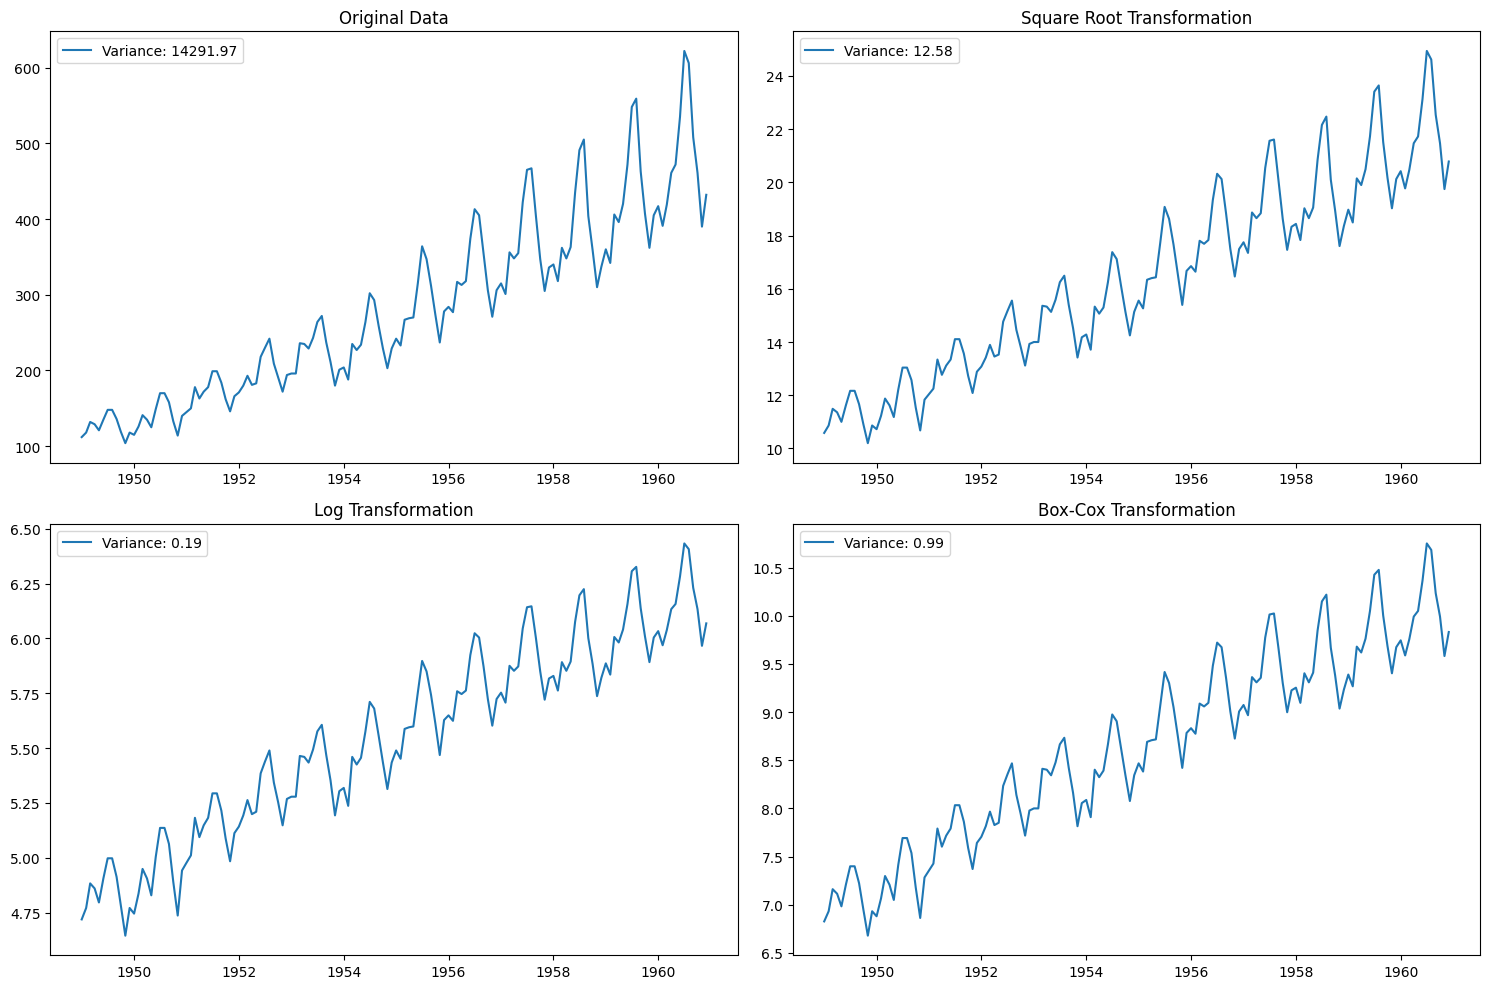

In [ ]:
#we apply log, sqrt, boxcox and arch transformations to compare their heteroscedasticity
data['log'] = np.log(data['#Passengers'])
data['sqrt'] = np.sqrt(data['#Passengers'])
data['boxcox'] , _ = scipy.stats.boxcox(data['#Passengers'])
data['original'] = data['#Passengers'] #original dataset without modifier 


#We calculate the variance of the original and transformed data to compare their heteroscedasticity
original_variance = np.var(data['original'])
log_variance = np.var(data['log'])
sqrt_variance = np.var(data['sqrt'])
boxcox_variance = np.var(data['boxcox'])
print(f'Original Variance: {original_variance}')
print(f'Log Variance: {log_variance}')
print(f'Square Root Variance: {sqrt_variance}')
print(f'Box-Cox Variance: {boxcox_variance}')


fig, ax = plt.subplots(2, 2, figsize=(15, 10))
ax[0, 0].plot(data['original'])
ax[0, 0].set_title('Original Data')
ax[0,0].legend([f'Variance: {original_variance:.2f}'])
ax[1, 0].plot(data['log'])
ax[1, 0].set_title('Log Transformation')
ax[1,0].legend([f'Variance: {log_variance:.2f}'])
ax[0, 1].plot(data['sqrt'])
ax[0, 1].set_title('Square Root Transformation')
ax[0,1].legend([f'Variance: {sqrt_variance:.2f}'])
ax[1, 1].plot(data['boxcox'])
ax[1, 1].set_title('Box-Cox Transformation')
ax[1,1].legend([f'Variance: {boxcox_variance:.2f}'])

plt.tight_layout()
plt.show()



We can observe that the variance of the Logarithmic transformation is the lowest (0,19), although it is closely followed by the Box-Cox Transformation (0,99)
, both are much less than the variance from the original data, of (14291,97), being the Logarithmic the most homoscedastic. The log and box-cox transformation are the most fitting due to these are effective in cases when the variance increases with the level of the series.

### Tendency

The trend is the long-term behavior of the data.  

In our time series, we have a growing linear trend. In this section, you need to remove the trend, leaving a time series with a constant trend.

<div style="background-color: #567c9b; border-color: #111921; border-left: 5px solid #5288be; padding: 0.5em;">
<strong>Implementation:</strong>

Identify if there is a trend in the time series and what type it is.
Remove the trend from the data: If there is a trend, apply a method to remove it (0.5 points)
Plot the data without the trend. (0.5 points)
</div>

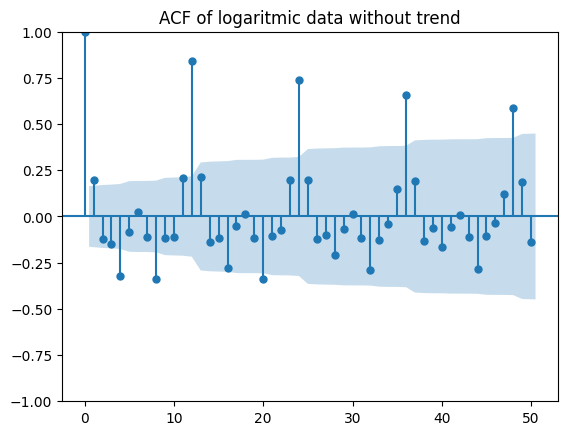

In [ ]:
#We use plot_acf to visualize the data without the trend
#diff() removes the trend from the data, and dropna() removes the NaN values that are created by diff()
plot_acf(data['log'].diff().dropna(), lags=50) 

"""
.diff() --> It subtracts the previous value from the current value.
.dropna()-->When you perform a difference, the very first data point has no "previous value" to subtract from.
ACF stands for Autocorrelation Function. It measures the correlation of a signal with a delayed version of itself.
Lags=50: You are looking back 50 time steps (months, usually).
"""


plt.title('ACF of logaritmic data without trend')
plt.show()

## How to interpret the graphic

- The horizontal axis (Lags): Represents the "delay" in time. Lag 12 compares today's data with data from 12 months ago. Lag 24 compares it with data from two years ago, and so on.

- Vertical axis (Autocorrelation): Measures the strength of the current data point and it's associated lagged one.

- The blue shaded area: This is the confidence interval. Any bars that fall within the blue area are considered "noise" or statistically insignificant. Bars that "stand out" indicate a real pattern that the model should recognize.

### Why do we use it to view tendency

When a series shows a trend (for example, flights always increase year after year), the data is highly correlated with its immediate neighbors.

- With a trend: You would see the bars descend very, very slowly, forming a kind of "ramp" or triangle that takes a long time to reach the blue area.

- Without a trend: The bars fall rapidly toward zero.

In our graphic we can see the values almost drop to zero quickly even at the beginning, this meaning we have eliminated the trend.

### Seasonality

We define seasonality as the cyclical variation that occurs in the data. In this section, seasonality should be identified and removed.

####  **Find the period of seasonality (0.5 points)**

<div style="background-color: #567c9b; border-color: #111921; border-left: 5px solid #5288be; padding: 0.5em;">
<strong>Implementation:</strong> First, you need to find the cycle, that is, how often the data repeats. To find it, you can use autocorrelation (i.e., *numpy* allows you to obtain the correlation coefficients).

The idea is to compare:

- The original series with the series starting from the second point (i.e., series[1:])
- The original series with the series starting from the third point (i.e., series[2:])
- ...

When the cycle starts over, the series will be very similar to the original series, and therefore, the correlation will be very high. The point where the correlation is maximum will be the cycle of the series.

Graphically show the coefficients of the first 26 autocorrelation values and determine the maximum value; this will be our seasonality.

    
<u>NOTA</u>: Si usais <i>numpy</i> para encontrar los coeficientes de correlación, las dos series que comparéis deben de tener la misma longitud. Para representar la serie original podéis eliminar los valores del final para que tenga la misma longitud que la serie "movida". Por ejemplo, en el primer caso podéis comparar serie[1:] con serie[:-1].
</div>

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Solution:</strong>
</div>

### WE IDENTIFY WERE THE SEASONALITY IS 

This because later on we will have to warn SARIMA of where the seasonality is.

Max Correlation: 0.9843 at Lag: 12


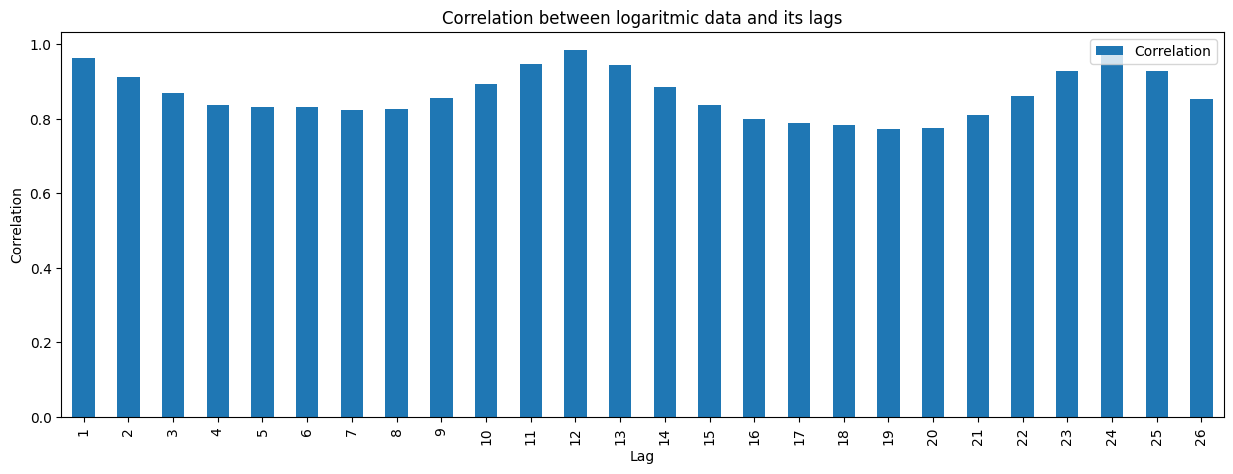

In [ ]:
#We define a training set
train_log = np.log(train['#Passengers'])

#We want to find the coeffcients of correlation between the logaritmic data and its lags
#We create a dataframe to store the lags and their correlation coefficients
lags = range(1, 27)
#.corr() calculates correlation between the logaritmic data and its lagged version, shift() shifts the data by the specified lag
correlations = [train_log.corr(train_log.shift(lag)) for lag in lags]
#pd.DataFrame creates a dataframe from the lags and their correlation coefficients
correlation_df = pd.DataFrame({'Lag': lags, 'Correlation': correlations})
#detect max correlation
max_corr = max(correlations)
#.index() returns the index of the first occurrence of the maximum correlation, and lags[] returns the corresponding lag
max_corr_lag = lags[correlations.index(max_corr)]
print(f'Max Correlation: {max_corr:.4f} at Lag: {max_corr_lag}')
correlation_df.plot(x='Lag', y='Correlation', kind='bar', figsize=(15, 5))
plt.title('Correlation between logaritmic data and its lags')
plt.xlabel('Lag')
plt.ylabel('Correlation')
plt.show()


####  Apply a SARIMA model

To address seasonality, we will apply a SARIMA model. The acronym stands for "Seasonal ARIMA," meaning an ARIMA model with seasonality (the one we just found).

The ARIMA model allows us to handle the noise left after removing heteroscedasticity, trend, and seasonality. It takes into account the following components:

- **AR**: Auto-regressive, denoted as *p*. It considers the correlation with its lags, meaning it looks at whether past observations influence the calculation of the next point.
- **I**: Integrated, denoted as *d*. This is the order of differencing, which, in our case, is not necessary since the series no longer has heteroscedasticity or trend.
- **MA**: Moving-average, denoted as *q*. It considers the correlation with the lags of the errors, meaning once the model is applied, it looks at the model errors versus the real data.

For more information on ARIMA, you can consult this link: https://otexts.com/fpp2/arima.html

SARIMA models depend on several parameters: (p,d,q)(P,D,Q)s, where the first set (lowercase) corresponds to AR, I, and MA of the normal series, and the second set (uppercase) corresponds to AR, I, and MA with seasonality.

To find these parameters, we need to look at the PACF (<i>partial autocorrelation function<i>) and ACF (<i>autocorrelation function<i>) plots.

The PACF plot determines the *p* parameter, i.e., the AR.


<div style="background-color: #567c9b; border-color: #111921; border-left: 5px solid #5288be; padding: 0.5em;">
<strong>Implementation:</strong>Apply a SARIMA model to the data without heteroscedasticity or trend. You can use SARIMAX (from <i>statsmodels.tsa.statespace.sarimax<i>) with the parameters you find.

- Create the ACF and PACF plots and determine the possible values for *p*, *P*, *Q*, *q* (1 point)
- Perform the ADF test. Comment on the results (0.75 points)
- Apply the SARIMAX model (0.5 points)
- Graphically show the model results along with the original series to compare if it fits well. Comment on the result (1.5 points)

Graphically show the model results along with the original series to compare if it fits well.
</div>

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Solution:</strong>
</div>

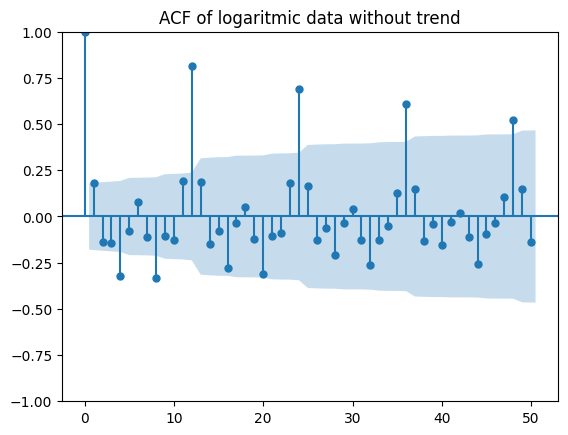

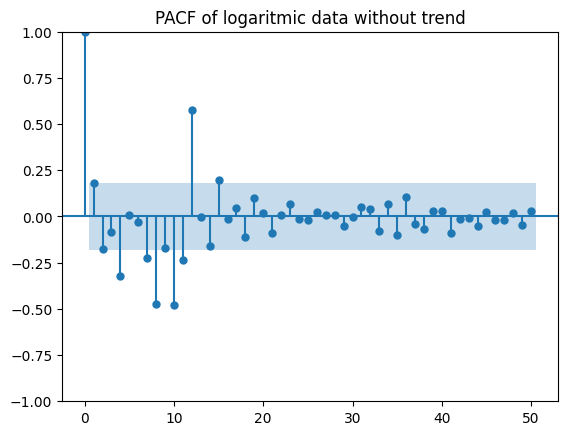

In [ ]:
#we start by defining the order of the ARIMA model. We will use the ACF and PACF plots to determine the order of the AR and MA components.
#We will use the logaritmic data for modeling, as it has less heteroscedasticity than the original data. We will also use the differenced logaritmic data to remove the trend and make the data stationary.
train_log_diff = train_log.diff().dropna()
plot_acf(train_log_diff, lags=50)
plt.title('ACF of logaritmic data without trend')
plot_pacf(train_log_diff, lags=50)
plt.title('PACF of logaritmic data without trend')
plt.show()

## ACF and PACF analyzing the possible values 

We know from theory that we can extract from ACF the Moving Average (MA) terms (q and Q) and from PACF the Auto-Regressive (AR) terms (p and P). Because ACF Measures the correlation between a point $y_t$​ and its past values. It captures both direct and indirect effects and Measures the correlation between $y_t$​ and a specific lag $y_{t−k}$​ after removing the effect of all intermediate lags.

### Non seasonal values

To find these values, we must look at where the bars drop into the blue shaded area, where any values that fall into it are considered "noise".

- PACF --> $p(AR)$: we are looking for the last lag that is significantly above the blue area before it drops. We see that in this case we have a $p = 1$ 
- ACF --> $q(MA)$: we search for the last lag that is significantly above the blue area. We see that in this case we have a $q = 1$ 
  
### Seasonal parameters

Seasonal AR (P): Look at the PACF. There is a huge significant spike at lag 12, a smaller one at 24, and then they mostly cut off. A "cutoff" in the PACF at seasonal lags suggests a Seasonal Auto-Regressive component. Value: $P=1$

Seasonal MA (Q): Look at the ACF. The spikes at 12, 24, 36 are "tailing off" (getting smaller slowly). When ACF tails off and PACF cuts off at seasonal lags, we usually prefer P over Q. Value: Start with $Q=0$.

# <span style="color:red">ADF TEST</span> 

The Augmented Dickey-Fuller (ADF) test is a formal statistical test used to determine if a time series is stationary or not.

In simple terms, the ADF test is a "stationarity lie detector." It checks for the presence of a unit root, which is a mathematical property that causes a series to be non-stationary (meaning its mean or variance changes over time).

When you run the test, you are testing two hypotheses:

- Null Hypothesis ($H_0$​): The series is non-stationary (it has a unit root).

- Alternative Hypothesis ($H_1$​): The series is stationary (no unit root).

To use SARIMA safely, we want to reject the Null Hypothesis. We do this by looking at the p-value. If the p-value is less than 0.05 (at a 5% significance level), we can say our data is stationary. If the data is still non-stationary. We might need another round of differencing.

In [ ]:
data['log'] = np.log(data['#Passengers'])

result = adfuller(data['log'].diff().dropna())

print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
print('Critical Values:')
for key, value in result[4].items():
    print(f'\t{key}: {value}')

ADF Statistic: -2.717130598388133
p-value: 0.07112054815085875
Critical Values:
	1%: -3.4825006939887997
	5%: -2.884397984161377
	10%: -2.578960197753906


As we can see, the p-value is higher than 0.05, this is because the seasonal spikes are so high, then we should run the ACF/PACF again but on the seasonally differenced data: data['log'].diff(1).diff(12).dropna(), doing this will shrink giant spikes at 12 and 24.

In [ ]:
data['log'] = np.log(data['#Passengers'])

train_log_n = adfuller(data['log'].diff(1).diff(12).dropna())

print(f'ADF Statistic: {train_log_n[0]}')
print(f'p-value: {train_log_n[1]}')
print('Critical Values:')
for key, value in result[4].items():
    print(f'\t{key}: {value}')

ADF Statistic: -4.4433249418311185
p-value: 0.00024859123113840924
Critical Values:
	1%: -3.4825006939887997
	5%: -2.884397984161377
	10%: -2.578960197753906


Now we finally have a $p-value$ < $0.05$ hence we can proceed with the SARIMAX model.

We can interpret the ADF Statistic and Critical Values knowing that for the series to be stationary, the ADF Statistic must be more negative (smaller) than the Critical Values. In this case we see that the ADF statistic is more negative than the critical values, thus our series is stationary.

## SARIMAX MODEL

The model requires two sets of parameters that we "extracted" from your ACF/PACF plots:

- Order (p,d,q): The non-seasonal part (short-term trends).
$$
p = 1, q = 1, d = 1 
$$ 
(this is needed when we feed the log transform to the model)

- Seasonal Order (P,D,Q,s): The seasonal part (yearly patterns).

$$
P = 1, D = 1, Q = 0, s = 12
$$ 
( D = 1 because the same reason as "d" and s = 12 because is where the repetitive peak is.)

c:\Users\ibane\anaconda3\envs\AnalysisD\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\ibane\anaconda3\envs\AnalysisD\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                      
Dep. Variable:                         #Passengers   No. Observations:                  120
Model:             SARIMAX(1, 1, 1)x(1, 1, [], 12)   Log Likelihood                 172.937
Date:                             Wed, 01 Apr 2026   AIC                           -337.874
Time:                                     10:50:45   BIC                           -327.701
Sample:                                 01-01-1949   HQIC                          -333.765
                                      - 12-01-1958                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0365      0.240     -0.152      0.879      -0.507       0.434
ma.L1         -0.3964      

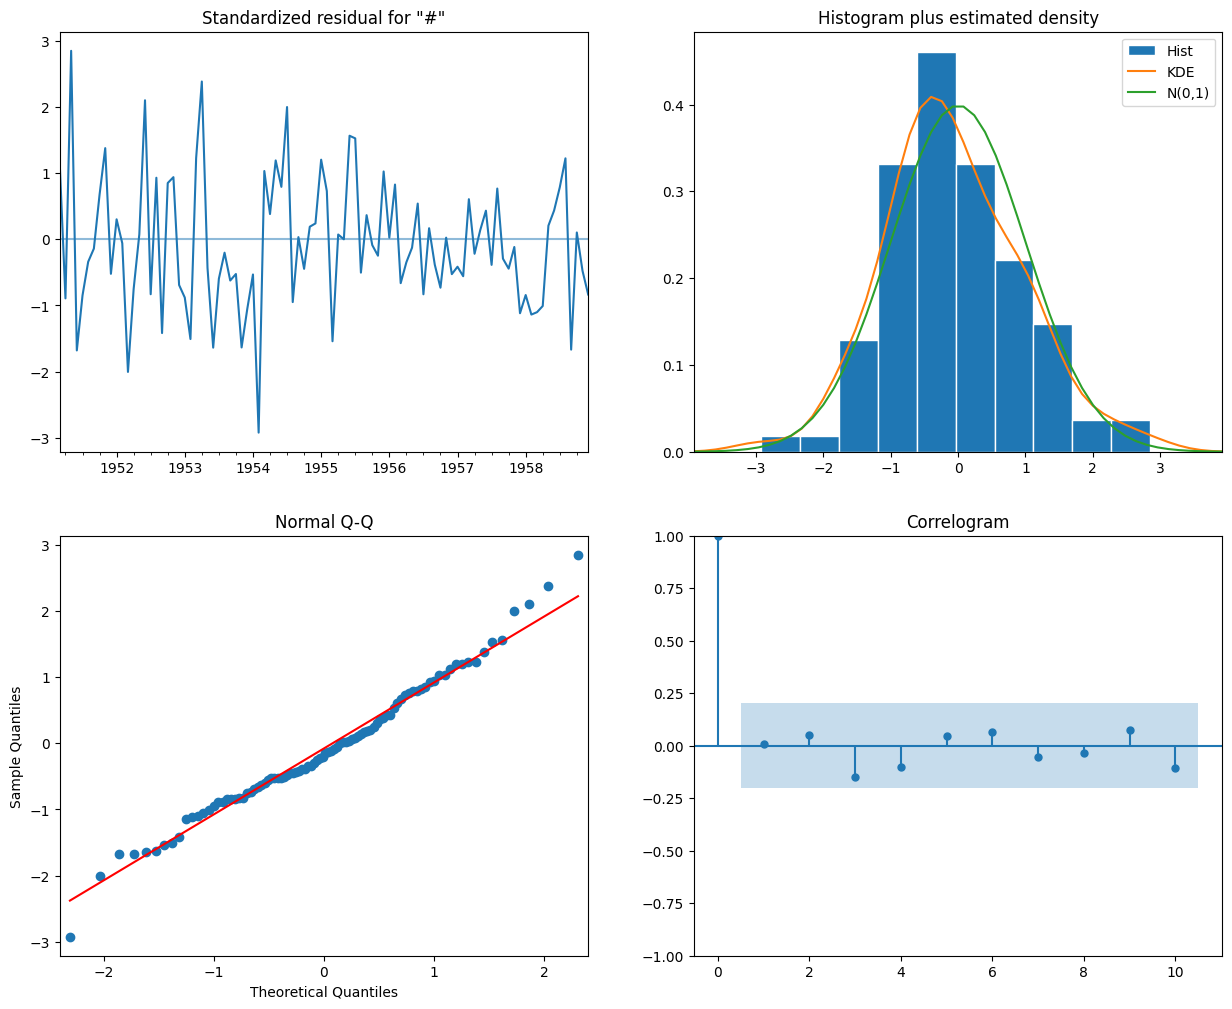

In [ ]:
# (p, d, q) x (P, D, Q, s)
train_log = np.log(train['#Passengers']) 

#  (The  d = '1's here handle the differencing for you)
my_order = (1, 1, 1) # Non-seasonal  
my_seasonal_order = (1, 1, 0, 12) #Seasonal

#Initialize the model using the LOG data
model = sm.tsa.statespace.SARIMAX(train_log,  # Pass the series, NOT the adfuller result
                                  order=my_order, 
                                  seasonal_order=my_seasonal_order,
                                  enforce_stationarity=False,
                                  enforce_invertibility=False)

# Fit and Plot
results = model.fit(disp=False)
print(results.summary())
results.plot_diagnostics(figsize=(15, 12))
plt.show()

## ANALYZING SARIMAX SUMMARY

Before analyzing our results we have the choice to tweak the season and non seasonal values in order to obtain better results. But we will first analyze the results with the deduced values:

PARAMETER $ar.L1$ (p-value 0.879): A p-value >0.05 means this parameter is not statistically significant. The model is trying to use the previous month's value to predict the current one, but it’s not helping. We will try next time with $p= 0$.

PARAMETER $ma.L1$ (p-value 0.082): This is borderline. It’s slightly above 0.05. It might be useful, but the model could be simpler without it.

PARAMETER $ar.S.L12$ (p-value 0.000): This confirms that the seasonal pattern (every 12 months) is extremely strong and the model is capturing it well.

PARAMETER Ljung-Box (Prob: 0.95): A high p-value here means our residuals (errors) are "white noise," meaning there's no information left for the model to learn.

PARAMETER Jarque-Bera (Prob: 0.39): This means our errors follow a Normal Distribution, which is a requirement for a reliable model.

## ANALYZING GRAPHS

Standardized Residuals are the errors overtime, to deduce if our model learns how to capture the variance we know the graph should look like "white noise" (no patterns or trends), in this case it meets our criteria.

Histogram plus estimated density is the distribution of the errors. For us to have good predictions we need the  orange line (KDE) should closely follow the green line (Normal distribution / N(0,1)). It looks like a bell curve centered at 0, meaning model's errors are random and unbiased.

Normal Q-Q compares the distribution of your residuals to a perfect normal distribution. For good predictions the dots should be on the line (at 45º angle), in this case we have a model that handles well outliers since almost all points are on the line.

Correlogram checks if there is any pattern left in the errors. All bars (except Lag 0) should be inside the blue shaded area. As we see we didn't left out any pattern in the errors.

## Changes 

ar.L1 (p-value 0.879): Has a p-value >0.05 means this parameter is not statistically significant. We will now try to reduce it's p value by setting the non seasonal parameter $p= 0$

c:\Users\ibane\anaconda3\envs\AnalysisD\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\ibane\anaconda3\envs\AnalysisD\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                      
Dep. Variable:                         #Passengers   No. Observations:                  120
Model:             SARIMAX(0, 1, 1)x(1, 1, [], 12)   Log Likelihood                 174.726
Date:                             Wed, 01 Apr 2026   AIC                           -343.452
Time:                                     10:50:46   BIC                           -335.790
Sample:                                 01-01-1949   HQIC                          -340.356
                                      - 12-01-1958                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.4308      0.091     -4.731      0.000      -0.609      -0.252
ar.S.L12      -0.4427      

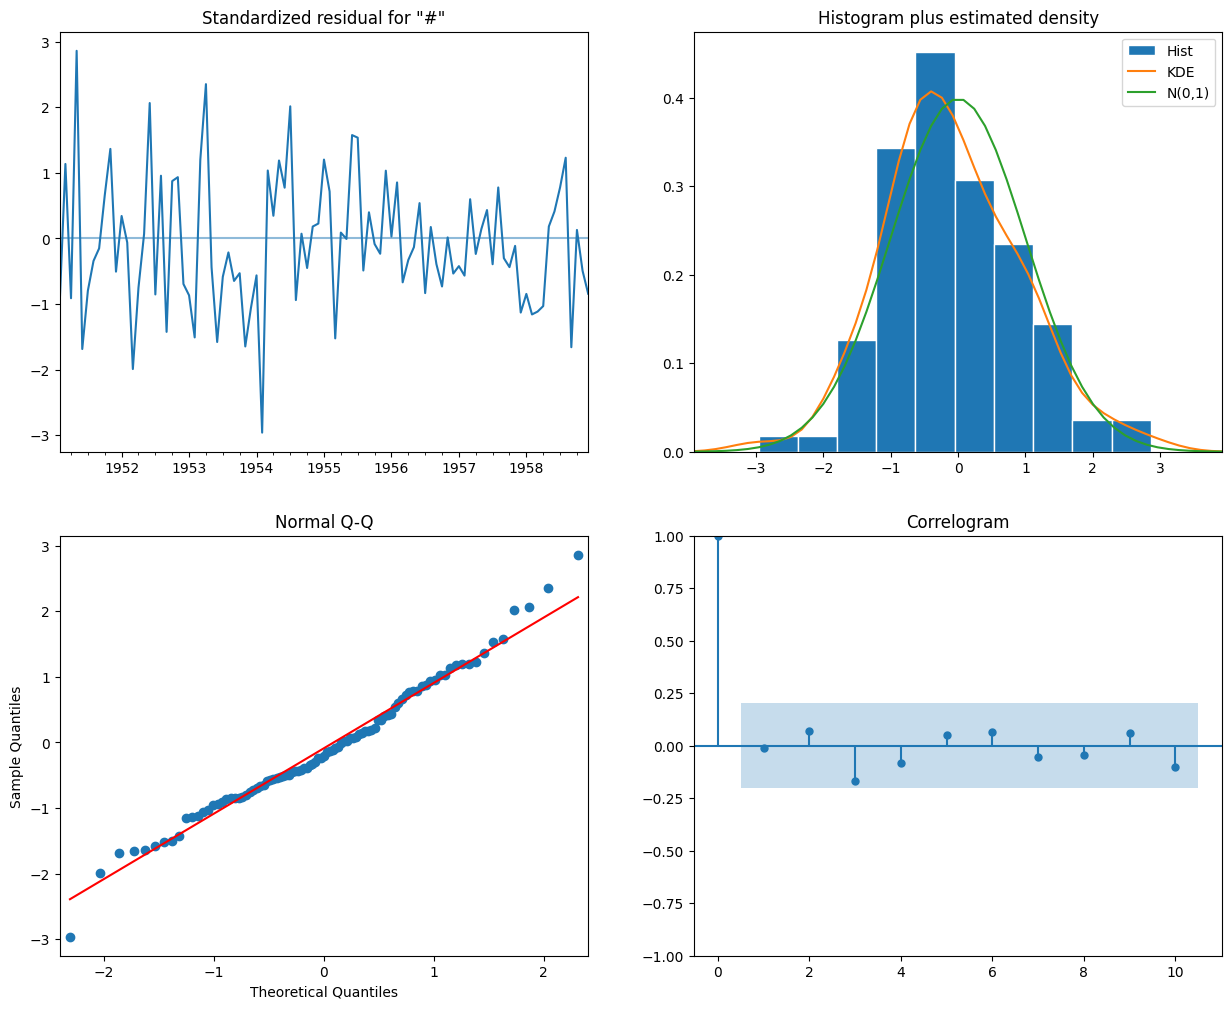

In [ ]:
# (p, d, q) x (P, D, Q, s)
train_log = np.log(train['#Passengers']) 

#  We changed the p = 0
my_order = (0, 1, 1) # Non-seasonal  
my_seasonal_order = (1, 1, 0, 12) #Seasonal

#Initialize the model using the LOG data
model = sm.tsa.statespace.SARIMAX(train_log,  # Pass the series, NOT the adfuller result
                                  order=my_order, 
                                  seasonal_order=my_seasonal_order,
                                  enforce_stationarity=False,
                                  enforce_invertibility=False)

# Fit and Plot
results = model.fit(disp=False)
print(results.summary())
results.plot_diagnostics(figsize=(15, 12))
plt.show()

Comparing both graphed results, nothing has changed.

## Forecast

Let's predict the next two years and compare the prediction with the actual data. We will follow the following steps:

   - Generate a prediction using SARIMA
   - Add the tendency previosuly observed
   - Add heterocedasticity

### SARIMA Forecast

We will use the SARIMA model we adjusted earlier to predict the next two years.

<div style="background-color: #567c9b; border-color: #111921; border-left: 5px solid #5288be; padding: 0.5em;">
<strong>Implementation:</strong> Generate two years of data using the SARIMA model fitted in the previous section. Plot the entire series (without heteroscedasticity or trend), differentiating the actual series from the two years of prediction using different colors. </div>

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Solución:</strong>
</div>

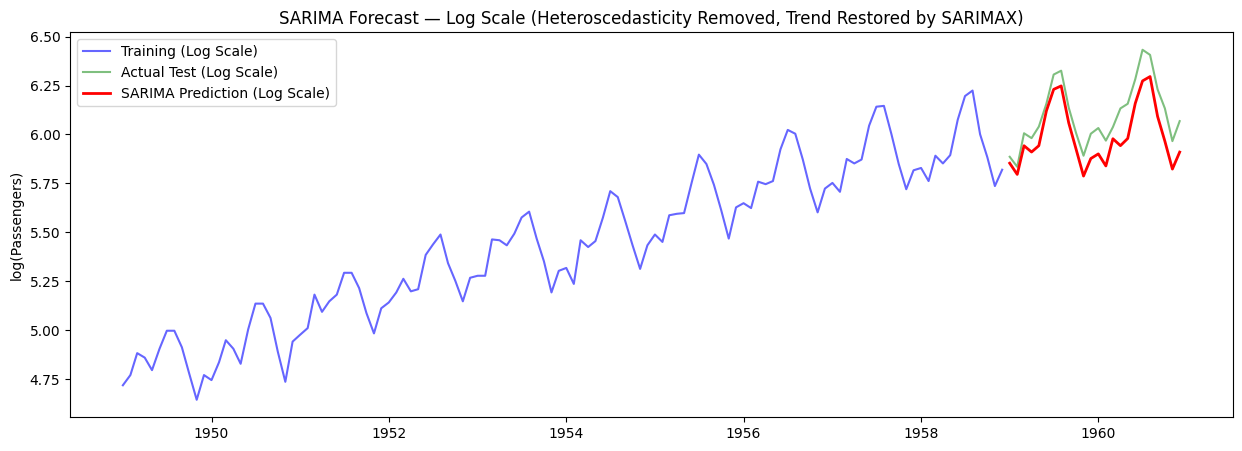

In [ ]:
pred = results.forecast(TEST_SIZE)  # Forecast returns values in log scale (SARIMAX integrates back the differencing automatically)


train_log_plot = np.log(train['#Passengers'])
test_log_plot  = np.log(test['#Passengers'])

train_log_plot.diff()
test_log_plot.diff()

fig, ax = plt.subplots(figsize=(15, 5))  # fig first, then ax
ax.plot(train.index, train_log_plot, label='Training (Log Scale)', color='blue', alpha=0.6)
ax.plot(test.index,  test_log_plot,  label='Actual Test (Log Scale)', color='green', alpha=0.5)
ax.plot(test.index,  pred,           label='SARIMA Prediction (Log Scale)', color='red', linewidth=2)
ax.set_title('SARIMA Forecast — Log Scale (Heteroscedasticity Removed, Trend Restored by SARIMAX)')
ax.set_ylabel('log(Passengers)')
ax.legend()
plt.show()


### Tendency

Previously, we saw that the time series data had a trend, and we removed it. Now we will need to add it back.



<div style="background-color: #567c9b; border-color: #111921; border-left: 5px solid #5288be; padding: 0.5em;">
<strong>Implementation:</strong>

- Add the trend to the prediction (0.5 points).
- Graph the entire series (without heteroscedasticity but with trend), differentiating the actual series from the two years of prediction using different colors. (0.5 points)
</div>

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Solution:</strong>
</div>

The code we showed before, is actually the code asked. Since the SARIMAX model had $d=1$, the .forecast() function automatically adds the trend back for us in the log scale. And since the log turned the series homocedastic, we don't need to remove any heteroscedasticity.

### Heterocedasticity

In the first section of the exercise, we saw that the time series had heteroscedasticity, and we removed it by transforming the data. In this section, we will perform the inverse transformation to add heteroscedasticity to our prediction.

<div style="background-color: #567c9b; border-color: #111921; border-left: 5px solid #5288be; padding: 0.5em;">
<strong>Implementation:</strong>

- Add heteroscedasticity to the previous series by applying the inverse function found in the first section (0.5 points).
    
- Graph the entire series, differentiating the actual series from the two years of prediction with different colors. (0.5 points)
</div>

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Solution:</strong>
</div>

To add heteroscedasticity, we apply the inverse of the log function, which is the exponential function (np.exp). This makes the variance grow again as the numbers get larger—exactly what we saw in the raw data.

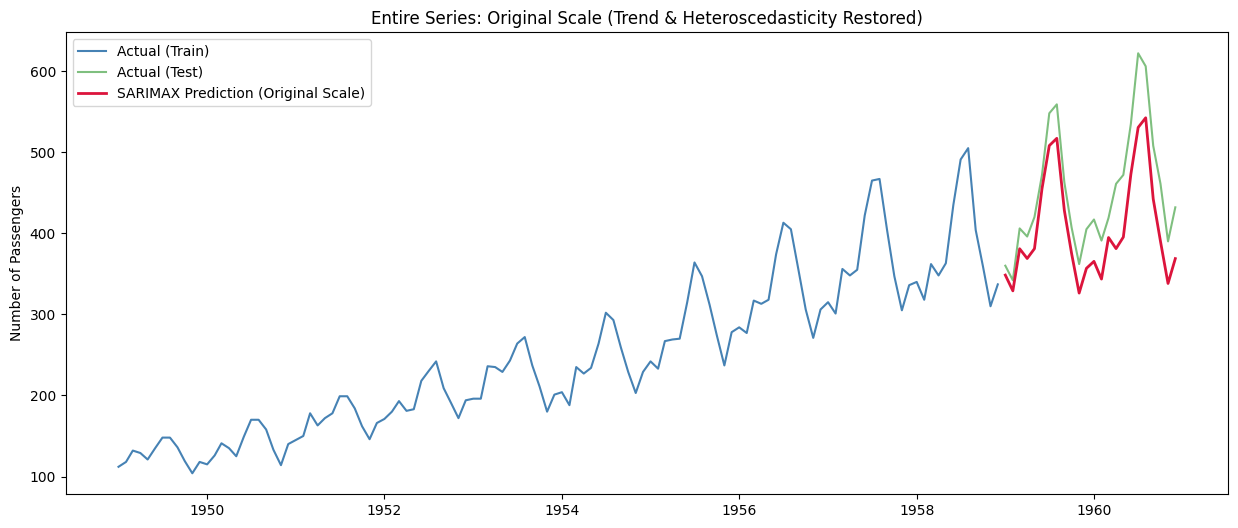

In [ ]:
# Add heteroscedasticity by applying the inverse function (np.exp)
# This brings us back to the original unit: Number of Passengers
forecast_original = np.exp(pred)

plt.figure(figsize=(15, 6))

#raw historical data
plt.plot(train.index, train['#Passengers'], label='Actual (Train)', color='steelblue')
plt.plot(test.index, test['#Passengers'], label='Actual (Test)', color='green', alpha=0.5)

# Plot the final prediction with trend AND heteroscedasticity
plt.plot(test.index, forecast_original, label='SARIMAX Prediction (Original Scale)', color='crimson', linewidth=2)

plt.title('Entire Series: Original Scale (Trend & Heteroscedasticity Restored)')
plt.ylabel('Number of Passengers')
plt.legend()
plt.show()

<div style="background-color: #567c9b; border-color: #111921; border-left: 5px solid #5288be; padding: 0.5em;">
<strong>Implementation:</strong>
Comment on all the results obtained during the exercise and reason whether the results are good or bad, explaining why. In case they are not entirely optimal, discuss what you could have done to improve them (1.25 points).
</div>

## RESULT ANALYSIS 

After setting up all the necessary data treatment methods in order to create a good SARIMA forecasting model, we can now analyze the results we have obtained. Before doing so let's review what we've done so far.

1. Handling Variance (The Log Transform)
2. Removing the Trend (Differencing)
3. Forensic Analysis (ACF and PACF):
From these test we obtained the correct parameters for our SARIMAX model
    
The model requires two sets of parameters that we "extracted" from your ACF/PACF plots:

- Order (p,d,q): The non-seasonal part (short-term trends).
$$
p = 1, q = 1, d = 1 
$$ 

- Seasonal Order (P,D,Q,s): The seasonal part (yearly patterns).

$$
P = 1, D = 1, Q = 0, s = 12
$$ 

4. Statistical Validation (ADF Test)
We used this test mathematically prove that our transformations successfully made the data stationary (p<0.05). At first it yielded a value higher than 0.05, then to solve this issue we differentiated again the dataset (diff(12)) and finally obtained a stationary dataset.

5. Training the SARIMAX Model
We fed the logged, stationary and without heterocedasticity data into the SARIMAX algorithm, with the parameters we found during the ACF and PACF test. Finally the model returned some parameters that gave us information about the time series (this parameters have been analyzed above). At the end we only had to change the
ar.L1 (p-value 0.879): Has a p-value >0.05 means this parameter is not statistically significant. We will now try to reduce it's p value by setting the non seasonal parameter $p= 0$.

6. Diagnostic Check (Residuals)
Before trusting the forecast, we looked at the "errors" the model made. To ensure the errors were White Noise (random). If the errors were random (normal distribution, no correlation in ACF), it meant the model had extracted 100% of the useful information. (We already have a result analysis of the graphs above).

7. Forecasting and "The Reversal"
Finally, we asked the model for 24 steps into the future. Because the forecast was in "log units," we applied np.exp() to bring the numbers back to actual passenger counts. In the graph obtained, the predicted trendline matches the seasonality and data pattern, we can conclude that our model has made good predictions 
